In [1]:
#Task 1 — Retail Sales Forecasting
#Objective:-
#Analyze retail sales data to identify seasonal trends and forecast future sales using basic time
#series analysis:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1 Load Dataset:

In [7]:
df=pd.read_csv("Features data set.csv")
df.head(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,12/03/2010,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,19/03/2010,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,26/03/2010,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,02/04/2010,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,09/04/2010,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [6]:
df.shape

(8190, 12)

In [13]:
df.columns

Index(['Store', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')

In [8]:
#Step 2: Data Preparation:

In [10]:
# Convert Date column to datetime with the correct format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')  # Specify day/month/year format

# Sort data
df = df.sort_values('Date')

# Set Date as index
df.set_index('Date', inplace=True)

# Check missing values
print(df.isnull().sum())

Store              0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


In [11]:
#Step 3: Aggregate Sales (if needed):

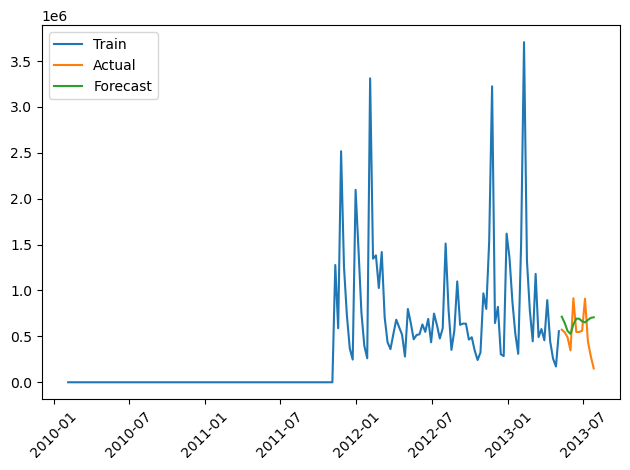

In [14]:
# Create proxy sales
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df['Sales'] = df[markdown_cols].fillna(0).sum(axis=1)

# Aggregate time series
ts = df.groupby('Date')['Sales'].sum().sort_index()

# Train-test split
train = ts[:-12]
test = ts[-12:]

# Fit ARIMA (p,d,q) → (5,1,2) is a good starting point
model = ARIMA(train, order=(5,1,2))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=12)

# Plot
plt.figure()
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
!pip install prophet

  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 331.4 kB/s eta 0:00:35
   - -------------------------------------- 0.5/12.1 MB 331.4 kB/s eta 0:00:35
   

20:06:11 - cmdstanpy - INFO - Chain [1] start processing
20:06:23 - cmdstanpy - INFO - Chain [1] done processing


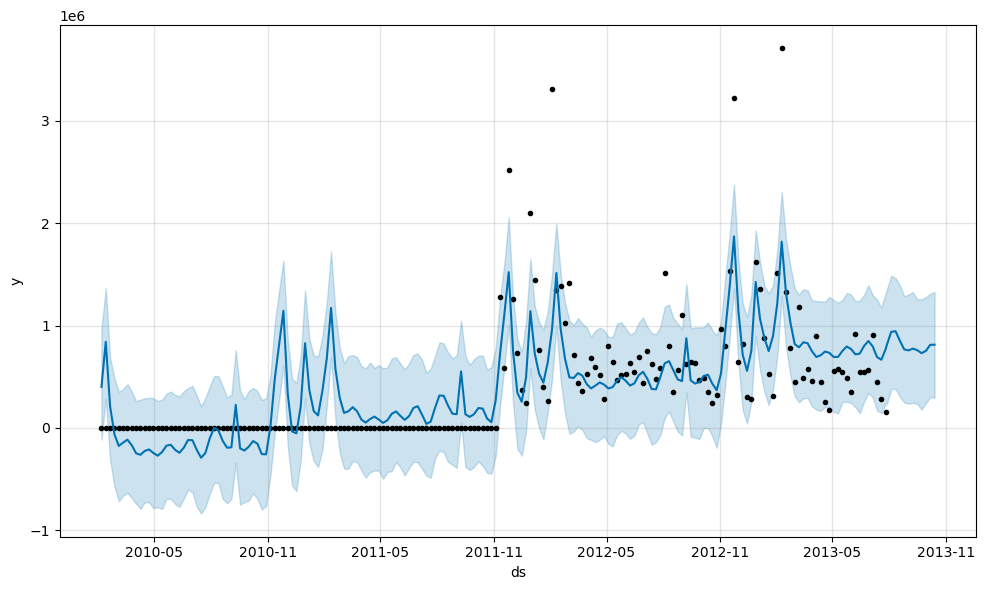

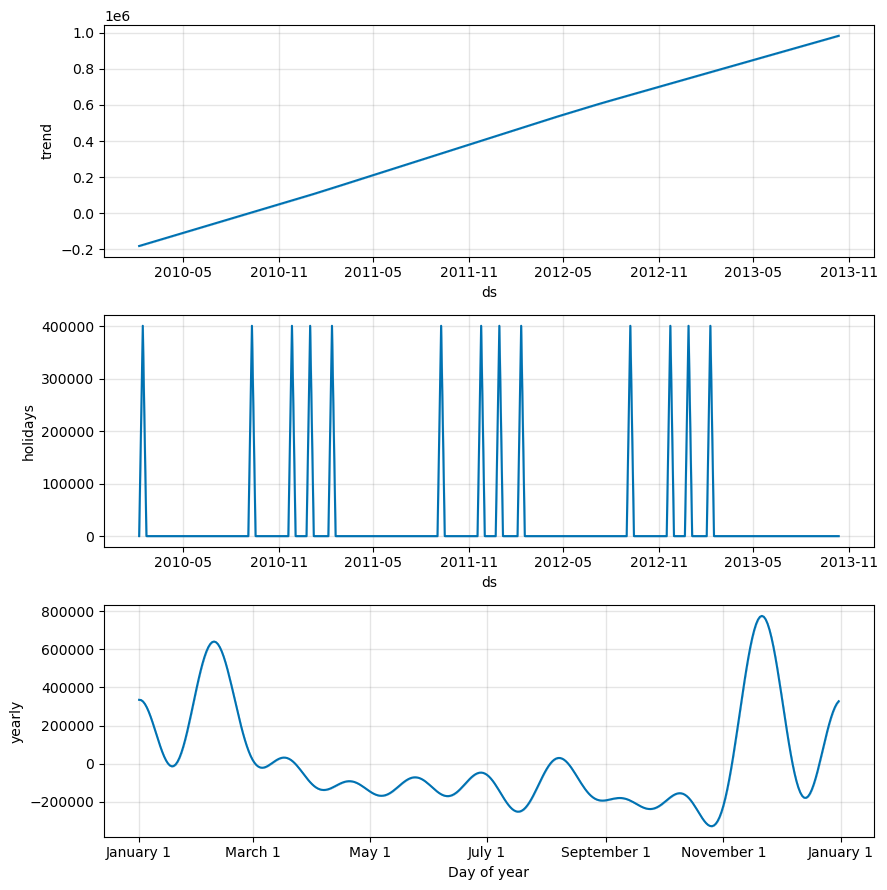

In [16]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data
df = pd.read_csv("Features data set.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df['Sales'] = df[markdown_cols].fillna(0).sum(axis=1)

ts = df.groupby('Date')['Sales'].sum().reset_index()

# Prophet format
ts = ts.rename(columns={'Date': 'ds', 'Sales': 'y'})

# Initialize model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Add holidays effect
holidays = df[df['IsHoliday'] == True][['Date']].drop_duplicates()
holidays = holidays.rename(columns={'Date': 'ds'})
holidays['holiday'] = 'holiday'

model = Prophet(holidays=holidays)

# Fit
model.fit(ts)

# Future dates
future = model.make_future_dataframe(periods=12, freq='W')

# Forecast
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.show()

# Components (trend + seasonality)
model.plot_components(forecast)
plt.show()

In [ ]:
#TASK 2: Customer Segmentation (Clustering):

In [26]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
## Load data:
df = pd.read_csv("customer_segmentation.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [29]:
df.shape

(2240, 29)

In [30]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [31]:
# Select numeric features
features = df.select_dtypes(include=['int64', 'float64'])

In [32]:
# Handle missing values
features = features.fillna(features.median())

In [33]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [35]:
# Scale data
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

In [36]:
# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled)

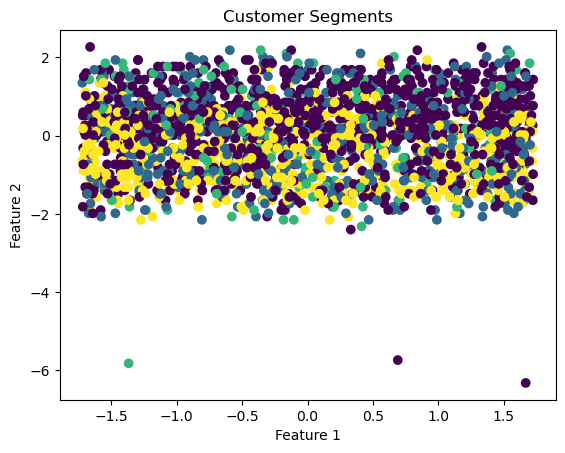

In [38]:
# Visualization
plt.figure()
plt.scatter(scaled[:, 0], scaled[:, 1], c=df['Cluster'])
plt.title("Customer Segments")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [39]:
# Cluster summary
summary = df.groupby('Cluster')[features.columns].mean()
print(summary)

                  ID   Year_Birth        Income   Kidhome  Teenhome  \
Cluster                                                               
0        5656.526777  1971.673807  34643.056158  0.803311  0.438169   
1        5707.053333  1967.875556  74192.634529  0.048889  0.228889   
2        5571.608187  1969.356725  81926.739645  0.052632  0.128655   
3        5399.097973  1964.378378  57477.257679  0.234797  0.944257   

           Recency    MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                                       
0        49.309640   40.309640   4.948393        22.994158         7.251217   
1        49.397778  490.988889  71.735556       431.097778       105.048889   
2        49.830409  874.701754  56.426901       469.128655        77.052632   
3        48.334459  454.221284  20.109797       128.611486        27.300676   

         ...  NumWebVisitsMonth  AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  \
Cluster  ...         

In [40]:
# Total spending (Monetary)
spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Purchase frequency
purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Engagement (campaign responses)
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                 'AcceptedCmp4','AcceptedCmp5','Response']
df['Engagement'] = df[campaign_cols].sum(axis=1)

# Discount behavior (deal purchases)
df['Discount_Sensitivity'] = df['NumDealsPurchases']

# -------------------------------
# Segmentation Logic
# -------------------------------

def segment_customer(row):
    
    if row['Total_Spending'] > df['Total_Spending'].quantile(0.75):
        return "High Spenders"
    
    elif row['Total_Purchases'] > df['Total_Purchases'].quantile(0.75):
        return "Loyal Customers"
    
    elif row['Discount_Sensitivity'] > df['Discount_Sensitivity'].quantile(0.75):
        return "Discount Seekers"
    
    elif row['Engagement'] == 0:
        return "Low Engagement Users"
    
    else:
        return "Average Customers"

# Apply segmentation
df['Segment'] = df.apply(segment_customer, axis=1)

# -------------------------------
# Summary
# -------------------------------

segment_summary = df.groupby('Segment')[[
    'Total_Spending','Total_Purchases','Engagement','Discount_Sensitivity'
]].mean()

print(segment_summary)

# Count of customers per segment
print(df['Segment'].value_counts())

                      Total_Spending  Total_Purchases  Engagement  \
Segment                                                             
Average Customers         270.359281         8.347305    1.257485   
Discount Seekers          348.521739        11.571906    0.344482   
High Spenders            1490.475000        19.992857    1.067857   
Low Engagement Users      185.821573         7.315524    0.000000   
Loyal Customers           849.680180        21.513514    0.405405   

                      Discount_Sensitivity  
Segment                                     
Average Customers                 1.832335  
Discount Seekers                  5.257525  
High Spenders                     1.857143  
Low Engagement Users              1.671371  
Loyal Customers                   2.846847  
Segment
Low Engagement Users    992
High Spenders           560
Discount Seekers        299
Loyal Customers         222
Average Customers       167
Name: count, dtype: int64


In [ ]:
#Visualization:

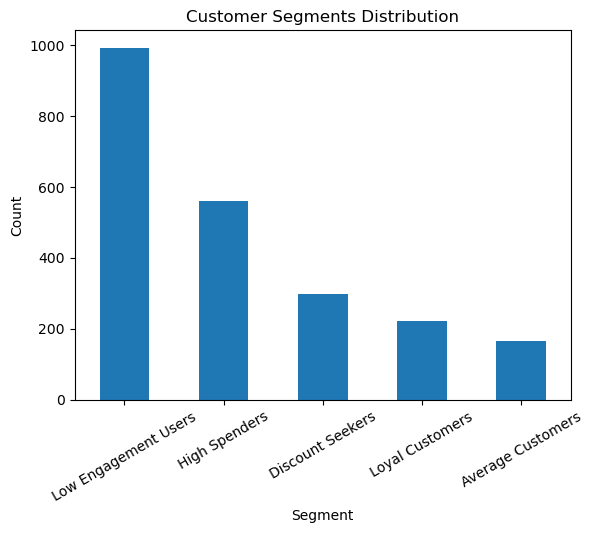

In [41]:
df['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [43]:
#Customer Segmentation Visualization:
spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_Spending'] = df[spending_cols].sum(axis=1)

purchase_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

df['Engagement'] = df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                       'AcceptedCmp4','AcceptedCmp5','Response']].sum(axis=1)

df['Discount_Sensitivity'] = df['NumDealsPurchases']

In [44]:
# Prepare Data for Clustering:
features = df[['Total_Spending','Total_Purchases','Engagement','Discount_Sensitivity']]
# Handle missing values
features = features.fillna(features.median())
# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
# KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled)

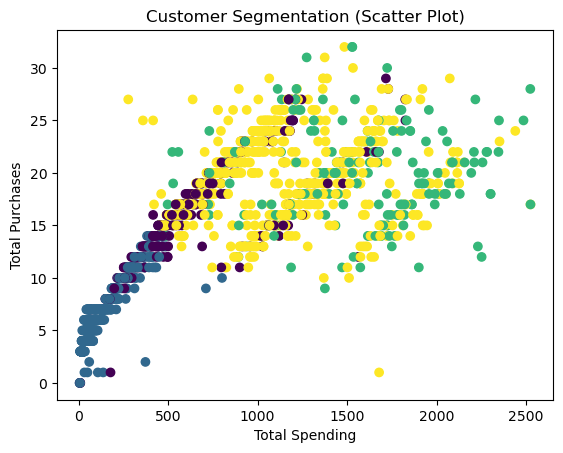

In [45]:
# 📊 Scatter Plot:
plt.figure()
plt.scatter(df['Total_Spending'], df['Total_Purchases'], c=df['Cluster'])
plt.xlabel("Total Spending")
plt.ylabel("Total Purchases")
plt.title("Customer Segmentation (Scatter Plot)")
plt.show()

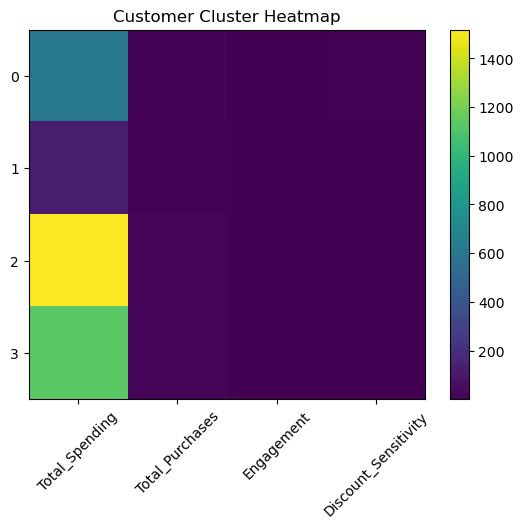

In [46]:
cluster_summary = df.groupby('Cluster')[features.columns].mean()
plt.figure()
plt.imshow(cluster_summary, aspect='auto')
plt.xticks(range(len(cluster_summary.columns)), cluster_summary.columns, rotation=45)
plt.yticks(range(len(cluster_summary.index)), cluster_summary.index)
plt.title("Customer Cluster Heatmap")
plt.colorbar()
plt.show()

In [47]:
# Print Summary:
print(cluster_summary)

         Total_Spending  Total_Purchases  Engagement  Discount_Sensitivity
Cluster                                                                   
0            615.566434        15.479021    0.363636              6.185315
1            112.876966         6.221092    0.157262              1.878816
2           1518.478947        19.626316    2.800000              1.368421
3           1127.972182        19.329429    0.285505              1.680820


In [ ]:
#Task 3 : Social Media Sentiment Analysis:

In [50]:
#Step 1: Install Required Libraries:

In [49]:
!pip install nltk

In [52]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

In [53]:
# Download resources (run once)
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TOSHIBA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\TOSHIBA\AppData\Roaming\nltk_data...


True

In [55]:
# Load Dataset
# -----------------------------
df = pd.read_csv("sentimentdataset.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [56]:
df.shape

(732, 15)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [58]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [59]:
# Select text column (adjust if needed)
text_col = df.columns[0]

In [60]:
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [61]:
# Data Cleaning
# -----------------------------
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"#\w+", "", text)           # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)       # remove special chars
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df[text_col].apply(clean_text)

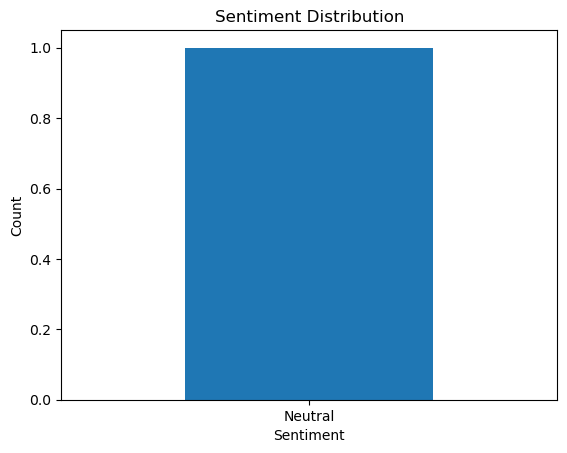

In [62]:
# Remove duplicates
df = df.drop_duplicates(subset='clean_text')

# -----------------------------
# Sentiment Analysis (VADER)
# -----------------------------
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['clean_text'].apply(get_sentiment)

# -----------------------------
# Visualization
# -----------------------------
sentiment_counts = df['Sentiment'].value_counts()

plt.figure()
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [63]:
# Output Results
# -----------------------------
print(df[['clean_text','Sentiment']].head())
print("\nSentiment Summary:\n", sentiment_counts)

  clean_text Sentiment
0              Neutral

Sentiment Summary:
 Sentiment
Neutral    1
Name: count, dtype: int64


In [64]:
!pip install wordcloud

In [65]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer

In [66]:
# Download resources (run once)
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TOSHIBA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\TOSHIBA\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [68]:
# Load Dataset
# -----------------------------
df = pd.read_csv("sentimentdataset.csv")

In [69]:
# Assume text column + date column
text_col = df.columns[0]
date_col = df.columns[1] if len(df.columns) > 1 else None

In [70]:
# Data Cleaning
# -----------------------------
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df[text_col].apply(clean_text)

In [71]:
# Sentiment Analysis (VADER)
# -----------------------------
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['clean_text'].apply(get_sentiment)

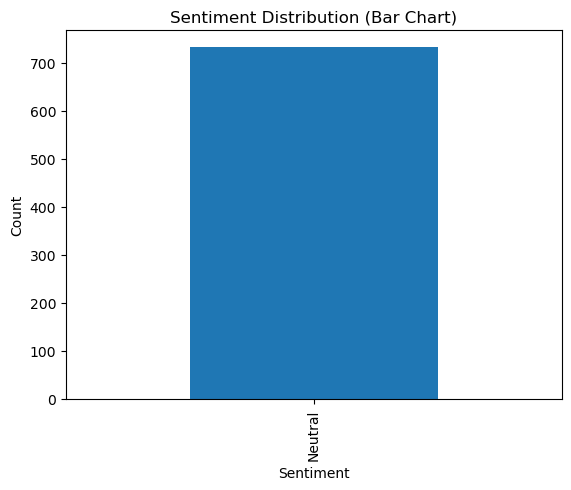

In [72]:
# 📊 1. Sentiment Distribution
# -----------------------------
sentiment_counts = df['Sentiment'].value_counts()

# Bar Chart
plt.figure()
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution (Bar Chart)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


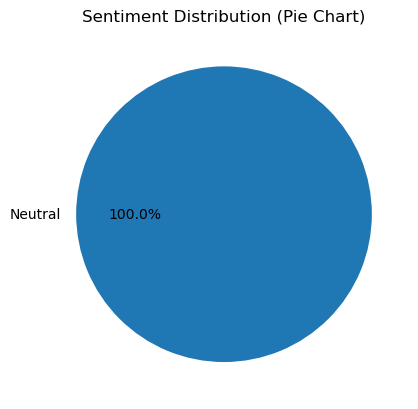

In [73]:
# Pie Chart
plt.figure()
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution (Pie Chart)")
plt.ylabel("")
plt.show()

<Figure size 640x480 with 0 Axes>

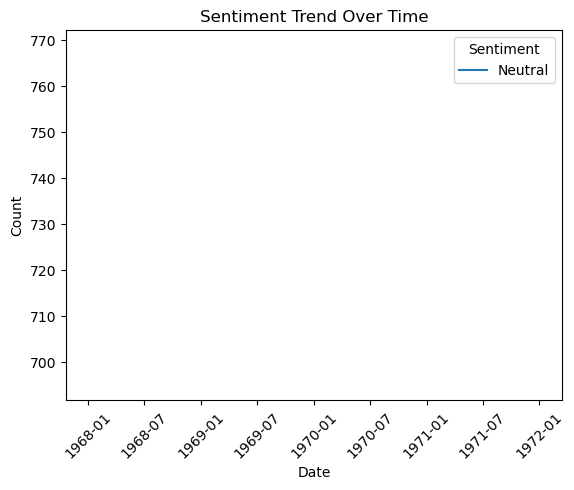

In [77]:
# 📈 3. Sentiment Trend Over Time
# -----------------------------
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    trend = df.groupby([df[date_col].dt.date, 'Sentiment']).size().unstack().fillna(0)

    plt.figure()
    trend.plot()
    plt.title("Sentiment Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [80]:
# 4. Insights (Auto Summary)
# -----------------------------
total = len(df)
positive_pct = (sentiment_counts.get('Positive',0)/total)*100
negative_pct = (sentiment_counts.get('Negative',0)/total)*100

print("\n=== INSIGHTS ===")

if positive_pct > negative_pct:
    print(" Overall sentiment is positive. Customers are generally satisfied.")
else:
    print(" Negative sentiment is high. Customer dissatisfaction detected.")

print(f"Positive: {positive_pct:.2f}%")
print(f"Negative: {negative_pct:.2f}%")


=== INSIGHTS ===
 Negative sentiment is high. Customer dissatisfaction detected.
Positive: 0.00%
Negative: 0.00%


In [79]:
print("\n=== RECOMMENDATIONS ===")

print("- Improve customer engagement through personalized responses")
print("- Address negative feedback quickly (customer support priority)")
print("- Leverage positive sentiment in marketing campaigns")
print("- Monitor trends regularly to detect reputation risks early")


=== RECOMMENDATIONS ===
- Improve customer engagement through personalized responses
- Address negative feedback quickly (customer support priority)
- Leverage positive sentiment in marketing campaigns
- Monitor trends regularly to detect reputation risks early
